# Data Loading & First Look 

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import joblib

In [52]:
brain = pd.read_csv("Brain Rot Cases Dataset.csv")

In [53]:
brain.shape

(1675, 19)

In [54]:
brain.info()

<class 'pandas.DataFrame'>
RangeIndex: 1675 entries, 0 to 1674
Data columns (total 19 columns):
 #   Column                                                                                                                                                                                                                                           Non-Null Count  Dtype
---  ------                                                                                                                                                                                                                                           --------------  -----
 0   Age                                                                                                                                                                                                                                              1675 non-null   int64
 1   Gender                                                                                         

In [55]:
brain.head()

,Age,Gender,Educational Level,How many hours do you spend daily on social media,Do you prefer using technology for work or leisure?,How many hours do you spend in front of computer screens or smartphones daily?,Do you feel that you use social media excessively?,Do social media platforms affect your social relationships?,Have you noticed a change in your mood after using technology?,"How would you rate your level of focus while working or studying? On a scale from 1 to 5, where 1 = very poor and 5 = excellent.",Do you find it difficult to concentrate when using technology (social media)?,How often do you feel distracted while trying to work or study due to technology (social media)?,"How would you rate your level of concern regarding technology use, particularly social media? On a scale from 1 to 5, where 1 = very low and 5 = excellent.","Do you believe that your use of social media negatively affects y How would you rate your level of concern regarding technology use, particularly social media? On a scale from 1 to 5, where 1 = very low and 5 = excellent.our mental health?",Do you believe that your use of social media negatively affects your mental health?,What platforms do you primarily use?,"""Do you think that using certain applications can help reduce feelings of mental fatigue?""\n","""Do you use any strategies to reduce technology usage?""","""If 'yes' was chosen for the above question, what are the strategies?"""
0,35,0,3,3,0,3,1,1,1,3,1,1,1,2,0,Facebook,1,0,Spending time with family
1,34,1,3,3,0,3,1,1,1,5,1,1,1,4,1,TikTok,1,1,Reading
2,32,1,3,3,0,3,1,1,0,5,0,1,1,1,0,Facebook,1,1,Exercising
3,24,0,2,3,0,3,1,0,0,5,1,0,1,3,1,Instagram,1,1,Spending time with family
4,21,1,2,2,1,2,1,0,1,2,1,1,1,3,1,Instagram,1,1,Reading


# Data Cleaning

In [56]:
brain.isnull().sum()

Age                                                                                                                                                                                                                                                 0
Gender                                                                                                                                                                                                                                              0
Educational Level                                                                                                                                                                                                                                   0
How many hours do you spend daily on social media                                                                                                                                                                                                   0
Do you prefer us

In [57]:
brain = brain.dropna()


In [58]:
brain.shape

(1654, 19)

In [59]:
brain.duplicated().sum()


np.int64(476)

In [60]:
brain = brain.drop_duplicates().reset_index(drop=True)

In [61]:
brain.duplicated().sum()

np.int64(0)

In [62]:
#Drop this column because it is duplicated
brain = brain.drop(columns=['How would you rate your level of concern regarding technology use, particularly social media? On a scale from 1 to 5, where 1 = very low and 5 = excellent.'])

In [63]:
brain.shape

(1178, 18)

# Exploratory Data Analysis (EDA) 

In [64]:
#renaming columns 
brain = brain.rename(columns={
    brain.columns[0]:  'age',
    brain.columns[1]:  'gender',
    brain.columns[2]:  'edu_level',
    brain.columns[3]:  'sm_hours',
    brain.columns[4]:  'prefer_tech',
    brain.columns[5]:  'screen_hours',
    brain.columns[6]:  'excessive',
    brain.columns[7]:  'affects_rel',
    brain.columns[8]:  'mood_change',
    brain.columns[9]:  'focus_level',
    brain.columns[10]: 'concentrate_diff',
    brain.columns[11]: 'work_distracted',
    brain.columns[12]: 'concern_level',   
    brain.columns[13]: 'affect_mental_health',    
    brain.columns[14]: 'platform',         
    brain.columns[15]: 'reduces_fatigue',  
    brain.columns[16]: 'uses_strategies',  
    brain.columns[17]: 'strategies_text',  
})

***EDA - Feature Engineering***


In [65]:
#age categories
brain['age_group'] = pd.cut(brain['age'],
        bins = [0, 18, 24, 34, 49, 100],
        labels = ['teen', 'young_adult', 'adult', 'mid_age', 'older'])

#creating a column for each platform
brain = brain.rename(columns={brain.columns[14]: 'platform'})
platform_map = {
    'tiktok':'tiktok', 'facebook':'facebook', 'instagram':'instagram',
    'telegram':'telegram', 'snapchat':'snapchat', 'youtube':'youtube',
    'whatsapp':'whatsapp', 'x':'x'
}
platform_lower = brain['platform'].str.lower().fillna('')
for name, kw in platform_map.items():
    brain[f'plat_{name}'] = platform_lower.str.contains(kw, na=False).astype(int)

#creating a list for all symptoms
sym = ['excessive', 'affects_rel', 'mood_change', 'concentrate_diff', 'work_distracted', 'affect_mental_health']
#calculates total symptoms
brain['symptom_score'] = brain[sym].sum(axis=1)

#calculates total screen time social media hours + screen time 
brain['total_screen_load'] = brain['sm_hours'] + brain['screen_hours'] 
#does social media dominates the screen time in total ?
brain['sm_dominance'] = brain['sm_hours'] / (brain['total_screen_load'] + 1)

#calculate how unfocus a person is (less = better)
brain['unfocus_score'] = 6 - brain['focus_level']

brain['brain_rot'] = (brain['symptom_score'] >= 5).astype(int)

brain.shape



(1178, 32)

In [66]:
brain = brain.drop(columns=['platform','strategies_text', 'age_group'])

In [67]:
list(brain.columns)

['age',
 'gender',
 'edu_level',
 'sm_hours',
 'prefer_tech',
 'screen_hours',
 'excessive',
 'affects_rel',
 'mood_change',
 'focus_level',
 'concentrate_diff',
 'work_distracted',
 'concern_level',
 'affect_mental_health',
 'reduces_fatigue',
 'uses_strategies',
 'plat_tiktok',
 'plat_facebook',
 'plat_instagram',
 'plat_telegram',
 'plat_snapchat',
 'plat_youtube',
 'plat_whatsapp',
 'plat_x',
 'symptom_score',
 'total_screen_load',
 'sm_dominance',
 'unfocus_score',
 'brain_rot']

***EDA - Visualizations***

***Do brain rot symptom scores differ across age groups?***

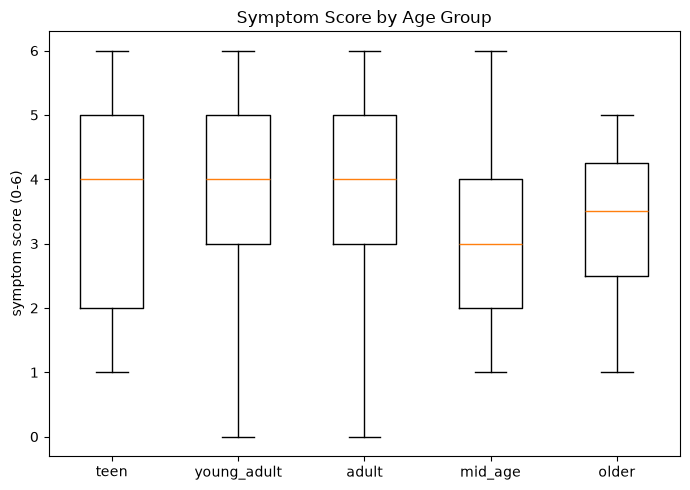

In [68]:
bins   = [0, 19, 30, 45, 60, 200]
labels = ['teen', 'young_adult', 'adult', 'mid_age', 'older']

grp = pd.cut(brain['age'], bins=bins, labels=labels, right=False)

data = [brain.loc[grp == g, 'symptom_score'].dropna() for g in labels]

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(data, tick_labels=labels)
ax.set_title('Symptom Score by Age Group')
ax.set_ylabel('symptom score (0-6)')
plt.tight_layout()
plt.show()

**Insight:**
Teens have the highest median symptom score and the widest spread, with scores dropping fairly steadily through young_adult → adult → mid_age → older. Age is a strong risk signal — younger users show meaningfully worse "brain rot" symptoms.

***Which Platforms Do High-Symptom Users Use Most?***

High-symptom users: 415


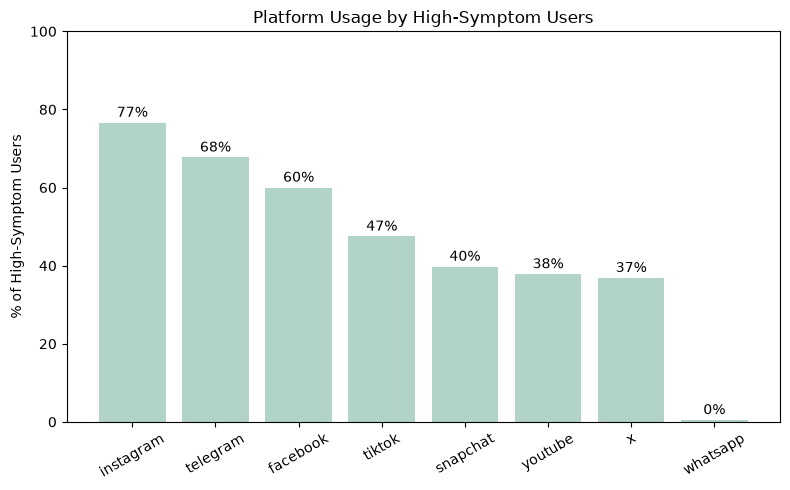

In [69]:
high_symptom = brain[brain['symptom_score'] >= 5]
print(f"High-symptom users: {len(high_symptom)}")

platform_cols = [f'plat_{name}' for name in platform_map]
usage_rate = high_symptom[platform_cols].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(usage_rate.index.str.replace('plat_',''), usage_rate.values, color='#b1d3c8')
ax.set_ylabel('% of High-Symptom Users')
ax.set_title('Platform Usage by High-Symptom Users')
ax.set_ylim(0, 100)
for b, v in zip(bars, usage_rate.values):
    ax.text(b.get_x()+b.get_width()/2, v+1.5, f'{v:.0f}%', ha='center')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Insight:**
Among the high-symptom users, usage is concentrated on a few platforms like Instagram, Telegram, Facebook, and Tiktok.

***How Many Users Feel Distracted Studying/Working Due to Social Media?***

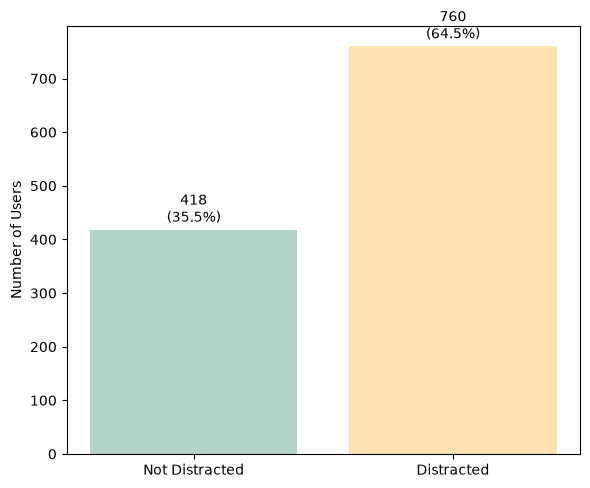

In [70]:
counts = brain['work_distracted'].value_counts().sort_index()
labels = ['Not Distracted', 'Distracted']
percentages = counts / counts.sum() * 100
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(labels, counts.values, color=['#b1d3c8', '#ffe0af'])
ax.set_ylabel('Number of Users')

for b, c, p in zip(bars, counts.values, percentages.values):
    ax.text(b.get_x()+b.get_width()/2, c+15, f'{c}\n({p:.1f}%)', ha='center')

plt.tight_layout()
plt.show()

**Insight**:
A large share of users report being distracted while working or studying due to social media (the "Distracted" bar dominates). This confirms distraction isn't a fringe issue — it's the majority experience in this sample.

***Does average focus decrease as screen time increases?***

C:\Users\lalsh\AppData\Local\Temp\ipykernel_15232\972204641.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=brain, x="screen_hours", y="focus_level", estimator="mean", errorbar="sd", palette="viridis")


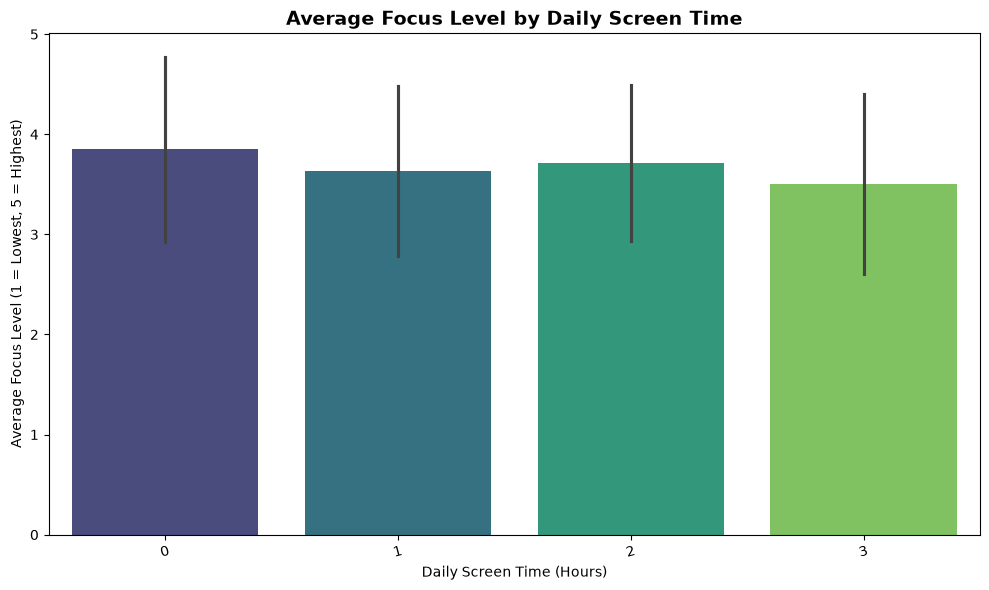

In [71]:

plt.figure(figsize=(10,6))

sns.barplot(data=brain, x="screen_hours", y="focus_level", estimator="mean", errorbar="sd", palette="viridis")

plt.title("Average Focus Level by Daily Screen Time", fontsize=14, weight="bold")
plt.xlabel("Daily Screen Time (Hours)")
plt.ylabel("Average Focus Level (1 = Lowest, 5 = Highest)")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

**Insight**:
Average focus level trends downward as daily screen hours increase, showing that the focus gets affected by screen time.

***Which brain rot symptoms tend to occur together?***

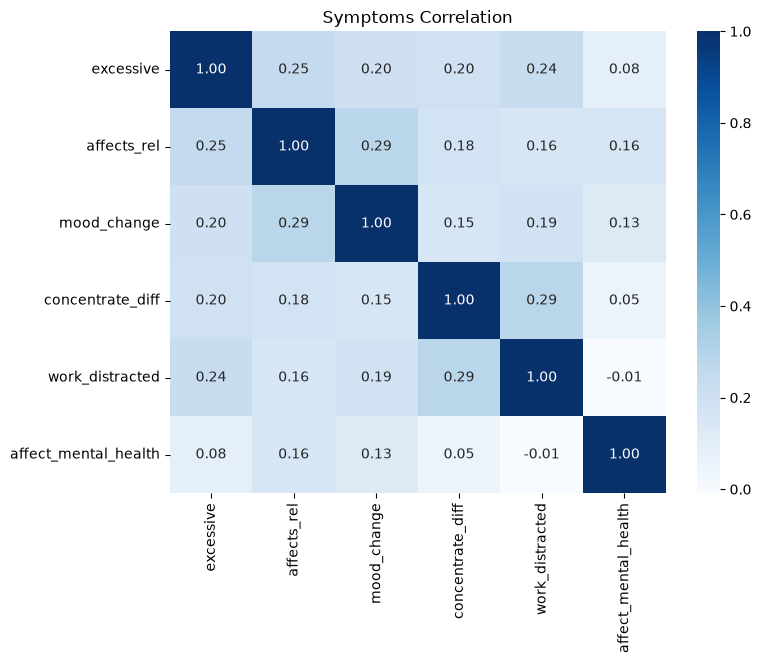

In [72]:
correlated_sym = brain[sym].corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlated_sym, annot=True, cmap="Blues", fmt=".2f")

plt.title("Symptoms Correlation")
plt.show()

**Insight**:
**`concentrate_diff` and `work_distracted` are the most tightly linked pair (0.28) and are also the two symptoms most connected to the rest of the set, while `affect_mental_health` is nearly isolated (its highest correlation with anything else is just 0.16), meaning it's capturing a distinct dimension the other five symptoms don't reach.**

***Do heavier technology users experience greater mood changes?***

C:\Users\lalsh\AppData\Local\Temp\ipykernel_15232\2981983174.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=brain,x="screen_hours",y="mood_change",estimator="mean",errorbar="sd",palette="viridis")


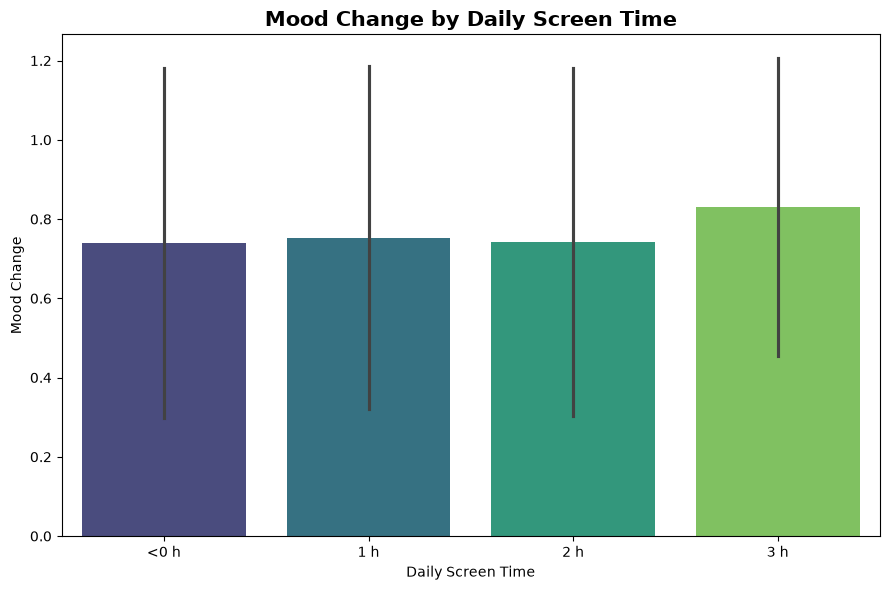

In [73]:


plt.figure(figsize=(9,6))

sns.barplot(data=brain,x="screen_hours",y="mood_change",estimator="mean",errorbar="sd",palette="viridis")

plt.title("Mood Change by Daily Screen Time", fontsize=15, weight="bold")
plt.xlabel("Daily Screen Time")
plt.ylabel("Mood Change")

plt.xticks(ticks=range(4), labels=["<0 h", "1 h", "2 h", "3 h"])

plt.tight_layout()
plt.show()

**Insight**:
Mood change worsens as screen time climbs from "<1h" toward "3h+", mirroring the focus-level trend. Screen time appears to be a consistent driver across both cognitive (focus) and emotional (mood) outcomes, not just one or the other.

# Target 1. Predicting Brain Rot Risk

###  Train and Test Split


In [74]:
leak_cols = ['excessive', 'affects_rel', 'mood_change','concentrate_diff', 'work_distracted','affect_mental_health', 'symptom_score']

X = brain.drop(columns=['brain_rot'] + leak_cols)
y = brain['brain_rot']

obj_cols = X.select_dtypes(include='object').columns.tolist()
X = pd.get_dummies(X, columns=obj_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Feature Scaling


In [75]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

### PCA



In [76]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca  = pca.transform(X_test_s)

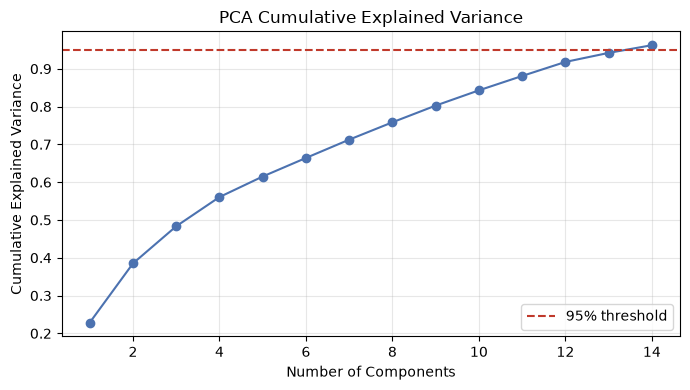

In [77]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cum_var) + 1), cum_var, marker='o', color='#4C72B0')
ax.axhline(0.95, color='#c0392b', linestyle='--', label='95% threshold')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA Cumulative Explained Variance')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Modeling

## Model 1 — Logistic Regression

In [78]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

y_predict_lr = lr.predict(X_test_s)
y_proba_lr= lr.predict_proba(X_test_s)[:, 1]

print("Logistic Regression trained.")
print(f"Accuracy: {accuracy_score(y_test, y_predict_lr):.2%}")

Logistic Regression trained.
Accuracy: 71.19%


In [82]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_s, y_train)

y_predict_xgb = xgb.predict(X_test_s)
y_proba_xgb   = xgb.predict_proba(X_test_s)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_predict_xgb):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_xgb):.4f}")

Accuracy: 0.7034
ROC-AUC:  0.7416


## Evaluation

### Accuracy

In [83]:
print(f"Logistic Regression: {accuracy_score(y_test, y_predict_lr):.4f}")
print(f"XGboost: {accuracy_score(y_test, y_predict_xgb):.4f}")

Logistic Regression: 0.7119
XGboost: 0.7034


### Precision

In [84]:
print(f"Logistic Regression: {precision_score(y_test, y_predict_lr):.4f}")
print(f"XGboost: {precision_score(y_test, y_predict_xgb):.4f}")

Logistic Regression: 0.6087
XGboost: 0.5915


### Recall

In [85]:
print(f"Logistic Regression: {recall_score(y_test, y_predict_lr):.4f}")
print(f"XGboost: {recall_score(y_test, y_predict_xgb):.4f}")

Logistic Regression: 0.5060
XGboost: 0.5060


### F1

In [86]:
print(f"Logistic Regression: {f1_score(y_test, y_predict_lr):.4f}")
print(f"XGboost: {f1_score(y_test, y_predict_xgb):.4f}")

Logistic Regression: 0.5526
XGboost: 0.5455


### ROC-AUC

In [87]:
print(f"Logistic Regression: {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"XGboost: {roc_auc_score(y_test, y_proba_xgb):.4f}")

Logistic Regression: 0.7613
XGboost: 0.7416


## Logistic Regression vs. XGboost

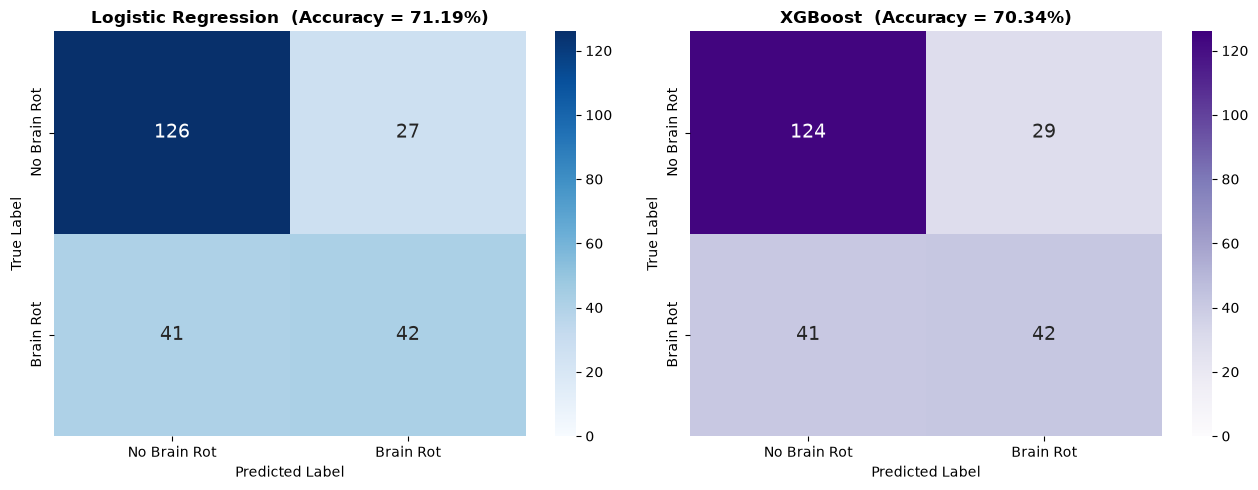

In [88]:
cm_lr  = confusion_matrix(y_test, y_predict_lr)
cm_xgb = confusion_matrix(y_test, y_predict_xgb)

class_names = ['No Brain Rot', 'Brain Rot']
vmax = max(cm_lr.max(), cm_xgb.max())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, cm, title, cmap in zip(
        axes,
        [cm_lr, cm_xgb],
        ['Logistic Regression', 'XGBoost'],
        ['Blues', 'Purples']):

    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True,
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, vmin=0, vmax=vmax,
                annot_kws={'size': 14})

    acc = np.trace(cm) / cm.sum()
    ax.set_title(f'{title}  (Accuracy = {acc:.2%})', fontsize=12, weight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

# Target 2. Predicting Perceived Mental Health Impact

In [89]:
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

### train and test split

In [90]:
target_2 = 'affect_mental_health'

other_symptoms = ['excessive', 'affects_rel', 'mood_change', 'concentrate_diff', 'work_distracted']

drop_2 = ([target_2, 'symptom_score', 'brain_rot', 'unfocus_score','strategies_text', 'age_group', 'platform'] + other_symptoms)

X2 = brain.drop(columns=[c for c in drop_2 if c in brain.columns])
y2 = brain[target_2]

obj_cols_2 = X2.select_dtypes(include='object').columns.tolist()
X2 = pd.get_dummies(X2, columns=obj_cols_2, drop_first=True)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

### Feature Scaling

In [91]:
sc2 = StandardScaler()

X2_train_s = sc2.fit_transform(X2_train)
X2_test_s  = sc2.transform(X2_test)

### PCA

In [92]:
pca2 = PCA(n_components=0.95, random_state=42)

X2_train_pca = pca2.fit_transform(X2_train_s)
X2_test_pca  = pca2.transform(X2_test_s)

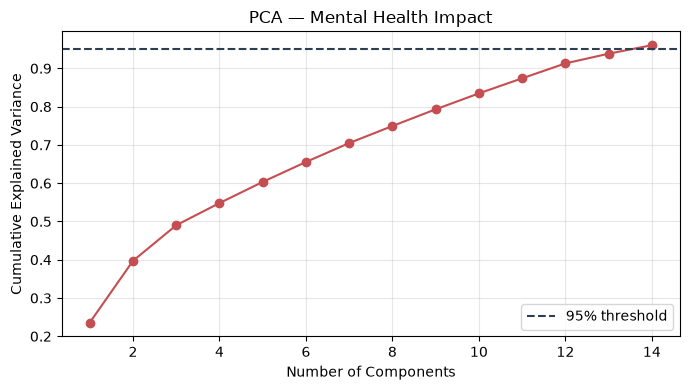

In [93]:
cum_var2 = np.cumsum(pca2.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cum_var2) + 1), cum_var2, marker='o', color='#C44E52')
ax.axhline(0.95, color='#2c3e50', linestyle='--', label='95% threshold')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA — Mental Health Impact')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Modeling 

In [94]:
models_2 = {
    'Gradient Boosting':GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,max_depth=4, random_state=42),
    'XGBoost':XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42),
}

preds_2, probas_2 = {}, {}

for name, m in models_2.items():
    m.fit(X2_train_s, y2_train)
    preds_2[name]  = m.predict(X2_test_s)
    probas_2[name] = m.predict_proba(X2_test_s)[:, 1]
    print(f"{name:22s} trained — Accuracy: {accuracy_score(y2_test, preds_2[name]):.4f}")

Gradient Boosting      trained — Accuracy: 0.8814
XGBoost                trained — Accuracy: 0.8729


### Accuracy

In [95]:
print(f"Gradient Boosting: {accuracy_score(y2_test, preds_2['Gradient Boosting']):.4f}")
print(f"XGBoost: {accuracy_score(y2_test, preds_2['XGBoost']):.4f}")

Gradient Boosting: 0.8814
XGBoost: 0.8729


### Precision

In [96]:
print(f"Gradient Boosting: {precision_score(y2_test, preds_2['Gradient Boosting']):.4f}")
print(f"XGBoost: {precision_score(y2_test, preds_2['XGBoost']):.4f}")

Gradient Boosting: 0.9249
XGBoost: 0.9202


### Recall

In [97]:
print(f"Gradient Boosting: {recall_score(y2_test, preds_2['Gradient Boosting']):.4f}")
print(f"XGBoost: {recall_score(y2_test, preds_2['XGBoost']):.4f}")

Gradient Boosting: 0.9426
XGBoost: 0.9378


### F1

In [98]:
print(f"Gradient Boosting: {f1_score(y2_test, preds_2['Gradient Boosting']):.4f}")
print(f"XGBoost: {f1_score(y2_test, preds_2['XGBoost']):.4f}")

Gradient Boosting: 0.9336
XGBoost: 0.9289


### ROC-AUC

In [99]:
print(f"Gradient Boosting: {roc_auc_score(y2_test, probas_2['Gradient Boosting']):.4f}")
print(f"XGBoost: {roc_auc_score(y2_test, probas_2['XGBoost']):.4f}")

Gradient Boosting: 0.8747
XGBoost: 0.8708


## Gradient Boosting vs. XGBoost

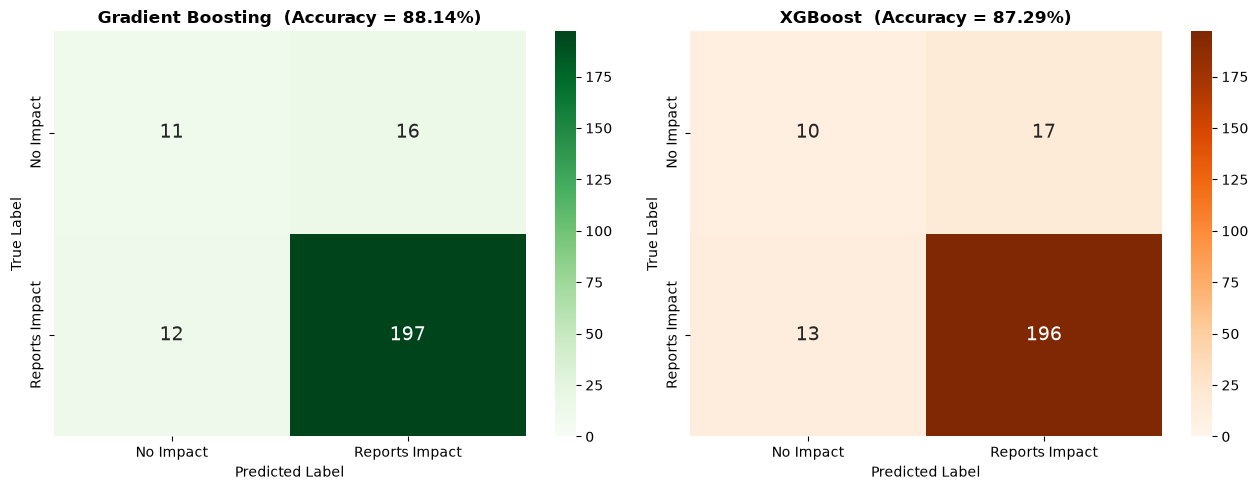

In [100]:
class_names_2 = ['No Impact', 'Reports Impact']
two = ['Gradient Boosting', 'XGBoost']

cms2 = [confusion_matrix(y2_test, preds_2[n]) for n in two]
vmax2 = max(cm.max() for cm in cms2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, cm, name, cmap in zip(axes, cms2, two, ['Greens', 'Oranges']):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True, xticklabels=class_names_2, yticklabels=class_names_2, ax=ax, vmin=0, vmax=vmax2, annot_kws={'size': 14})
    acc = np.trace(cm) / cm.sum()
    ax.set_title(f'{name}  (Accuracy = {acc:.2%})', fontsize=12, weight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()